# Wine Quality Prediction

## Project Overview

The objective of this project is to predict wine quality based on its chemical properties using Machine Learning classification algorithms.

The project includes:

- Data Loading
- Data Exploration
- Data Cleaning
- Exploratory Data Analysis
- Feature Selection
- Model Training
- Model Evaluation
- Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import SGDClassifier

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

## Load Dataset

Load the wine quality dataset into a pandas DataFrame.

In [2]:
wine = pd.read_csv("WineQT.csv")

wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


##Data Analysis
Before building the machine learning model, it is important to explore the dataset and understand its structure.

Pandas is used for data loading, manipulation, and analysis, while NumPy provides efficient numerical computations and array operations.

In [4]:
# Dataset Shape
wine.shape

(1143, 13)

In [5]:
# Dataset Information
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
# Check Missing Values
wine.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [7]:
# Statistical Summary
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


#Visualization

## Target Variable Distribution

Visualize the distribution of wine quality scores.

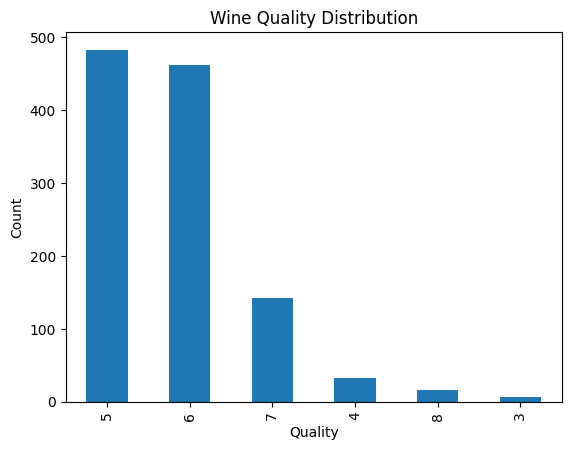

In [8]:
wine["quality"].value_counts().plot(kind="bar")

plt.xlabel("Quality")

plt.ylabel("Count")

plt.title("Wine Quality Distribution")

plt.show()

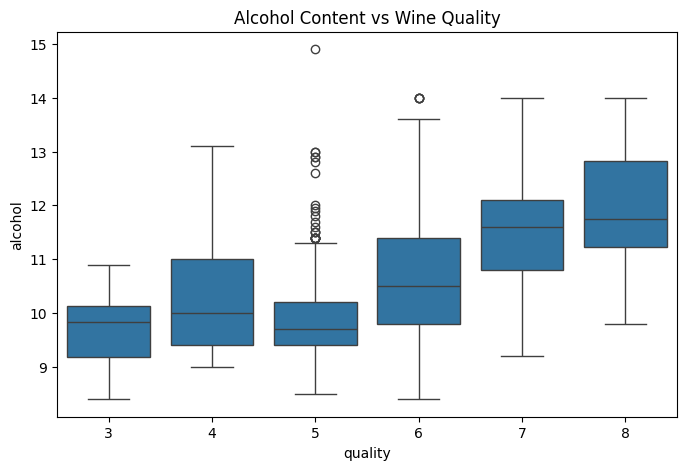

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x="quality",y="alcohol",data=wine)

plt.title("Alcohol Content vs Wine Quality")

plt.show()

**Interpretation:**

The distribution plot shows that most wine samples belong to the middle quality categories, while very low and very high-quality wines are less common. The boxplot indicates that wines with higher alcohol content generally tend to have better quality scores, suggesting alcohol is an important predictor of wine quality.

## Feature Selection

Separate input features and target variable.

In [9]:
X = wine.drop(["quality","Id"],axis=1)

y = wine["quality"]

## Split Dataset

Split the dataset into training and testing sets.

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Scaling Data

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Random Forest Classifier

In [25]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

print("Random Forest Accuracy:",accuracy_score(y_test,rf_pred))

Random Forest Accuracy: 0.7030567685589519


## Stochastic Gradient Descent Classifier

In [18]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

sgd = SGDClassifier(random_state=42)

sgd.fit(X_train_scaled, y_train)

sgd_pred = sgd.predict(X_test_scaled)

print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))

SGD Accuracy: 0.5021834061135371


## Support Vector Classifier (SVC)

In [20]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svc.fit(X_train_scaled, y_train)

svc_pred = svc.predict(X_test_scaled)

print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

SVC Accuracy: 0.6375545851528385


In [21]:
print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))
print("SGD Accuracy           :", accuracy_score(y_test, sgd_pred))
print("SVC Accuracy           :", accuracy_score(y_test, svc_pred))

Random Forest Accuracy : 0.7030567685589519
SGD Accuracy           : 0.5021834061135371
SVC Accuracy           : 0.6375545851528385


## Classification Report

In [14]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.80      0.76        96
           6       0.68      0.67      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.68      0.70      0.69       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

In [15]:
cm=confusion_matrix(y_test,rf_pred)

print(cm)

[[ 0  3  3  0  0]
 [ 0 77 18  1  0]
 [ 0 27 66  6  0]
 [ 0  0  8 18  0]
 [ 0  0  2  0  0]]


**Interpretation:**
The confusion matrix shows that the Random Forest model correctly classified most wine quality classes, with the highest number of predictions on the diagonal. Some misclassifications occurred between similar quality levels, indicating that wines with close chemical properties are difficult to distinguish. Overall, the model demonstrates good classification performance.


## Chemical Properties Analysis

The quality of wine is influenced by several chemical properties such as acidity, density, alcohol content, and sulphates.

A correlation heatmap helps identify the relationship between these chemical features and wine quality, allowing us to understand which variables have the greatest impact on the target variable.

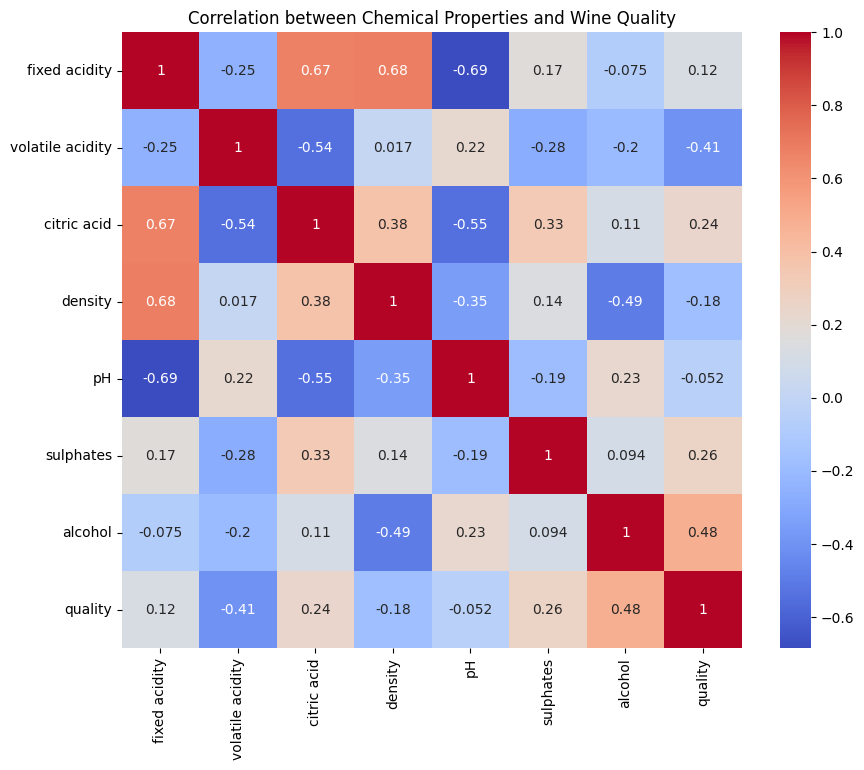

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

chemical_features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'quality'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    wine[chemical_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation between Chemical Properties and Wine Quality")

plt.show()

**Interpretation:**

The heatmap shows the correlation between different chemical properties and wine quality. Alcohol content has a positive relationship with wine quality, while volatile acidity tends to have a negative relationship. Understanding these correlations helps identify the most influential features for building an effective prediction model.